In [2]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\bhumi\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [3]:
# import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
# load the datatset

df=pd.read_excel(r"C:\Users\bhumi\Downloads\ApexPlanet_DataAnalytics_Dataset.xlsx")
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90


In [5]:
# Dataset Overview

print("Rows and Columns:", df.shape)
df.info()
df.describe()
df.describe(include='object')

Rows and Columns: (1000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1000 non-null   object 
 1   Order_Date     1000 non-null   object 
 2   Customer_ID    1000 non-null   object 
 3   Customer_Name  1000 non-null   object 
 4   Age            980 non-null    float64
 5   Gender         1000 non-null   object 
 6   City           987 non-null    object 
 7   Product        1000 non-null   object 
 8   Category       1000 non-null   object 
 9   Quantity       1000 non-null   int64  
 10  Unit_Price     1000 non-null   float64
 11  Total_Sales    1000 non-null   float64
dtypes: float64(3), int64(1), object(8)
memory usage: 93.9+ KB


,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,City,Product,Category
count,1000,1000,1000,1000,1000,987,1000,1000
unique,992,342,947,425,2,8,6,5
top,ORD100050,2025-04-16,CUST2515,Customer_359,Male,Patna,Mobile,Electronics
freq,9,10,3,8,511,135,184,354


In [7]:
# Numerical Statistics

df[['Quantity','Unit_Price','Total_Sales']].describe()

,Quantity,Unit_Price,Total_Sales
count,1000.000000,1000.000000,1000.000000
mean,5.435000,25486.783410,139399.439650
std,2.838632,14179.402361,114100.051546
min,1.000000,145.780000,437.340000
25%,3.000000,13895.722500,47066.632500
50%,5.000000,25398.740000,108594.025000
75%,8.000000,37512.382500,203722.882500
max,10.000000,49997.530000,493677.500000


In [8]:
# Category Frequency

df['Category'].value_counts()

Category
Electronics    354
Education      178
Furniture      159
Fashion        156
Grocery        153
Name: count, dtype: int64

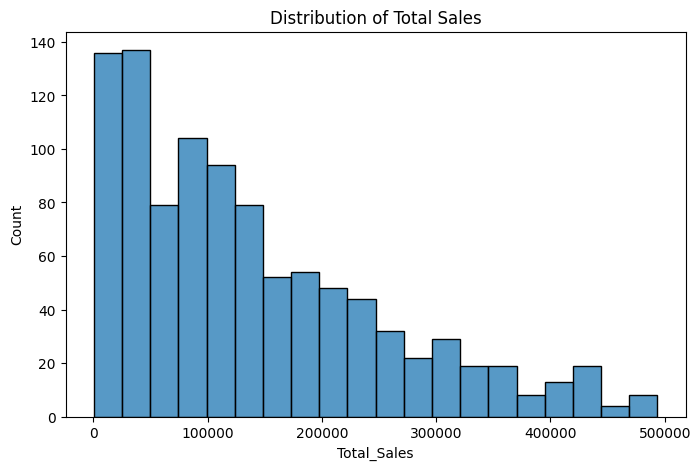

In [9]:
# Histogram:Total Sales

plt.figure(figsize=(8,5))
sns.histplot(df['Total_Sales'],bins=20)
plt.title("Distribution of Total Sales")
plt.show()

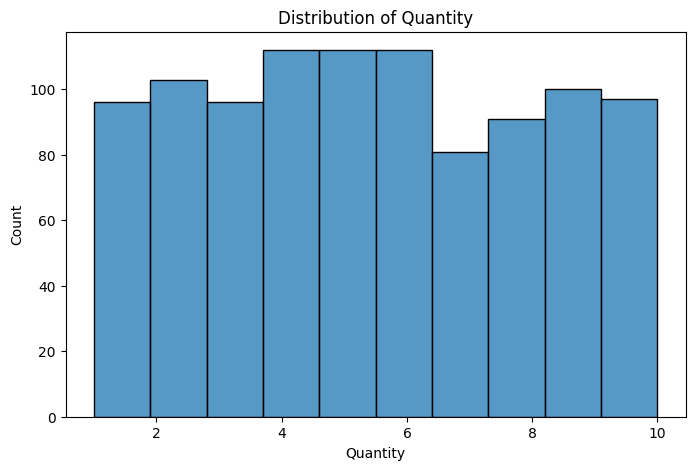

In [10]:
# Histogram:Qunatity

plt.figure(figsize=(8,5))
sns.histplot(df['Quantity'],bins=10)
plt.title("Distribution of Quantity")
plt.show()

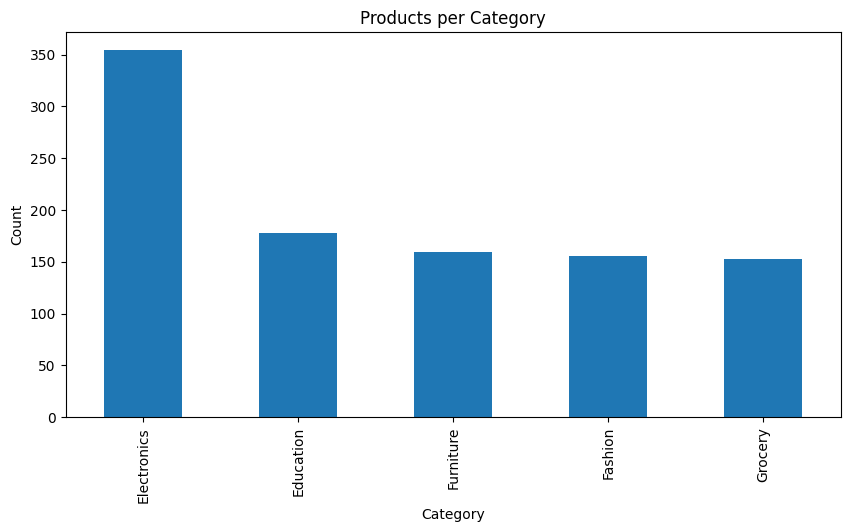

In [11]:
# Bar chart:Product Categories

plt.figure(figsize=(10,5))
df['Category'].value_counts().plot(kind='bar')
plt.title("Products per Category")
plt.ylabel("Count")
plt.show()

In [12]:
#convert dataframe into SQLite table

import sqlite3
conn = sqlite3.connect('sales.db')
df.to_sql('sales', conn, if_exists='replace', index=False)

1000

In [13]:
# Business Question 1
#Top 5 Products by Revenue

query = """
SELECT Product,
SUM(Total_Sales) AS Revenue
FROM sales
GROUP BY Product
ORDER BY Revenue DESC
LIMIT 5
"""
pd.read_sql(query, conn)

,Product,Revenue
0,Laptop,25443008.51
1,Mobile,25335573.19
2,Book,25031689.40
3,Rice,22231711.28
4,Chair,21521561.48


In [14]:
#Business Question 2
#Top Revenue by Category

query = """
SELECT Category,
SUM(Total_Sales) AS Revenue
FROM sales
GROUP BY Category
ORDER BY Revenue DESC
"""
pd.read_sql(query, conn)

,Category,Revenue
0,Electronics,50778581.70
1,Education,25031689.40
2,Grocery,22231711.28
3,Furniture,21521561.48
4,Fashion,19835895.79


In [15]:
#Business Question 3
#Average Sales per Category

query = """
SELECT Category,
AVG(Total_Sales) AS Avg_Sales
FROM sales
GROUP BY Category
"""
pd.read_sql(query, conn)

,Category,Avg_Sales
0,Education,140627.468539
1,Electronics,143442.321186
2,Fashion,127153.178141
3,Furniture,135355.732579
4,Grocery,145305.302484


In [16]:
# Business Question 4
# Highest Sellin Customer

query = """
SELECT Customer_Name,
SUM(Total_Sales) AS Revenue
FROM sales
GROUP BY Customer_Name
ORDER BY Revenue DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,Customer_Name,Revenue
0,Customer_335,1684832.52
1,Customer_138,1305932.64
2,Customer_266,1269445.22
3,Customer_375,1196934.33
4,Customer_274,1060340.15
5,Customer_343,1025447.16
6,Customer_415,967962.17
7,Customer_355,954513.58
8,Customer_1,952753.99
9,Customer_359,941957.21


In [17]:
# Business Question 5
# Monthly Revenue Trend

df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df.to_sql('sales', conn, if_exists='replace', index=False)
query = """
SELECT strftime('%m', Order_Date) AS Month,
SUM(Total_Sales) AS Revenue
FROM sales
GROUP BY Month
ORDER BY Month
"""
pd.read_sql(query, conn)

,Month,Revenue
0,01,10905580.72
1,02,11511181.46
2,03,13059899.94
3,04,12222700.17
4,05,10984689.25
5,06,12912332.64
6,07,11746226.80
7,08,9448471.22
8,09,9179896.29
9,10,12500936.50


In [18]:
# Business Question 6
# Total Quantity Sold by Category

query = """
SELECT Category,
SUM(Quantity) AS Total_Quantity
FROM sales
GROUP BY Category
ORDER BY Total_Quantity DESC
"""
pd.read_sql(query, conn)

,Category,Total_Quantity
0,Electronics,1978
1,Education,977
2,Furniture,855
3,Grocery,826
4,Fashion,799


In [19]:
# Business Question 7
# Top Customers by Orders

query = """
SELECT Customer_Name,
COUNT(Order_ID) AS Orders
FROM sales
GROUP BY Customer_Name
ORDER BY Orders DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,Customer_Name,Orders
0,Customer_359,8
1,Customer_375,7
2,Customer_53,6
3,Customer_335,6
4,Customer_165,6
5,Customer_15,6
6,Customer_104,6
7,Customer_103,6
8,Customer_98,5
9,Customer_468,5


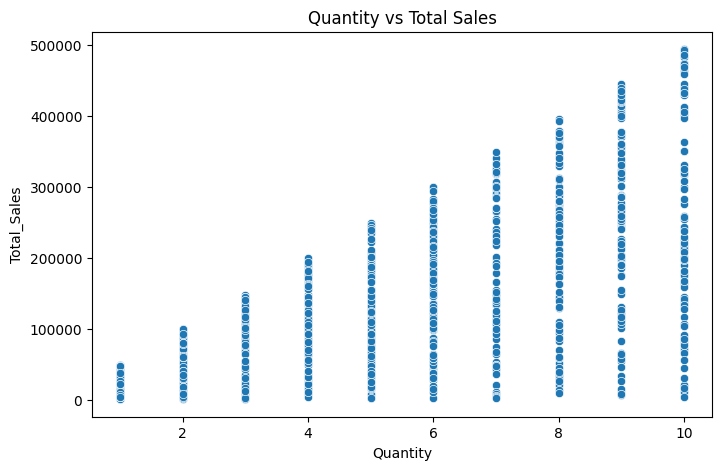

In [20]:
# Multivariate Analysis & Correlation
# Scatter plot

plt.figure(figsize=(8,5))
sns.scatterplot(
x='Quantity',
y='Total_Sales',
data=df
)
plt.title("Quantity vs Total Sales")
plt.show()

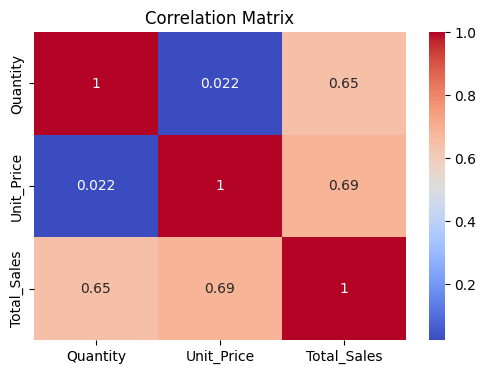

In [21]:
# Correlation Heatmap

corr = df[['Quantity',
           'Unit_Price',
           'Total_Sales']].corr()
plt.figure(figsize=(6,4))
sns.heatmap(
corr,
annot=True,
cmap='coolwarm'
)
plt.title("Correlation Matrix")
plt.show()

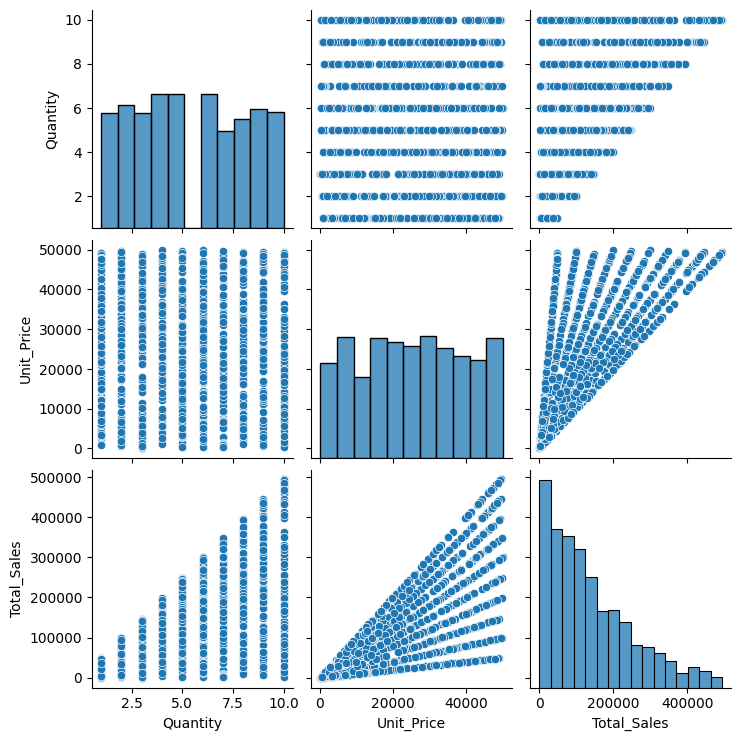

In [22]:
# Pair plot

sns.pairplot(
df[['Quantity',
    'Unit_Price',
    'Total_Sales']]
)
plt.show()

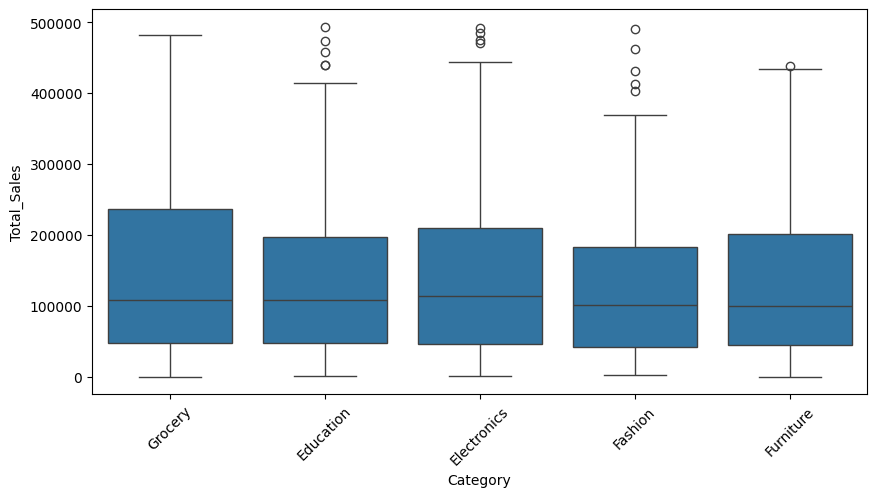

In [23]:
# Category vs Sales

plt.figure(figsize=(10,5))

sns.boxplot(
x='Category',
y='Total_Sales',
data=df
)
plt.xticks(rotation=45)
plt.show()

In [24]:
# Static Dashboard Mock-Up
# KPI-1 Total Revenue

total_revenue = df['Total_Sales'].sum()
print("Total Revenue =", total_revenue)

Total Revenue = 139399439.65


In [25]:
# KPI-2 Total Orders

total_orders = df['Order_ID'].nunique()
print("Total Orders =", total_orders)

Total Orders = 992


In [26]:
# KPI-3 Average Order Value

avg_order_value = df['Total_Sales'].mean()
print("Average Order Value =", avg_order_value)

Average Order Value = 139399.43965000001


In [27]:
# KPI-4 Total Customers

customers = df['Customer_ID'].nunique()
print("Total Customers =", customers)

Total Customers = 947


In [28]:
# KPI-5 Best Category

best_category = df.groupby('Category')['Total_Sales'].sum().idxmax()
print("Best Category =", best_category)

Best Category = Electronics
